# Chapter project - Learn tic-tac-toe by self-play, then grade it against perfect play

**Lecture 32, applied end to end.**

In the lecture the agent learned a $4\times4$ gridworld, and we could check it because value
iteration had already computed the exact answer $V^*$.

We are going to do the same thing to a **game** - and we can, because tic-tac-toe is small
enough to **solve exactly**. Minimax gives us the true value of every position, so every claim
in this notebook gets scored rather than admired.

### The question

> Can an agent that is told **only the rules and the final result** learn to play tic-tac-toe
> as well as a perfect player?

The answer is more interesting than yes or no, and Part 8 explains why.

### The plan

| Part | What we do |
|---|---|
| 0 | The game, and a perfect minimax opponent - our ground truth |
| 1 | **Baseline first:** how well does random play do? |
| 2 | Train Q-learning against a random opponent |
| 3 | **The trap.** Take that agent to a real opponent |
| 4 | Self-play |
| 5 | Grade every move against minimax |
| 6 | Turn exploration off and watch it collapse |
| 7 | Try to help it with reward shaping |
| 8 | The verdict - and why "did it win?" is the wrong question |

## Setup

Pure Python and numpy. No GPU, no libraries beyond what the course already uses.

In [1]:
%matplotlib inline

import random
from collections import defaultdict
from functools import lru_cache
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

SEED = 509
random.seed(SEED)
np.random.seed(SEED)

RED, BLUE, ORANGE = "#D90012", "#0033A0", "#F2A800"
plt.rcParams["figure.figsize"] = (10, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("ready")

ready


---
# Part 0 - The game, and the exact answer

A board is a tuple of 9 numbers: `0` empty, `1` for X, `2` for O. Using a tuple (not a list)
matters - it is hashable, so it can be a dictionary key, which is what makes tabular Q-learning
possible at all.

In [2]:
EMPTY, X, O = 0, 1, 2
LINES = [(0,1,2), (3,4,5), (6,7,8),      # rows
         (0,3,6), (1,4,7), (2,5,8),      # columns
         (0,4,8), (2,4,6)]               # diagonals

def winner(board):
    "Return X, O, or 0 if nobody has three in a row."
    for a, b, c in LINES:
        if board[a] != EMPTY and board[a] == board[b] == board[c]:
            return board[a]
    return 0

def legal_moves(board):
    return [i for i, v in enumerate(board) if v == EMPTY]

def play_move(board, cell, player):
    nxt = list(board)
    nxt[cell] = player
    return tuple(nxt)

def is_over(board):
    return winner(board) != 0 or not legal_moves(board)

EMPTY_BOARD = (EMPTY,) * 9
print("empty board:", EMPTY_BOARD)
print("legal moves:", legal_moves(EMPTY_BOARD))

empty board: (0, 0, 0, 0, 0, 0, 0, 0, 0)
legal moves: [0, 1, 2, 3, 4, 5, 6, 7, 8]


A way to actually look at a board, because we will be staring at these a lot.

In [3]:
def show(board):
    glyph = {EMPTY: ".", X: "X", O: "O"}
    rows = ["".join(f" {glyph[board[r * 3 + c]]} " for c in range(3)) for r in range(3)]
    print("\n---+---+---\n".join(rows))

demo = play_move(play_move(EMPTY_BOARD, 4, X), 0, O)
show(demo)

 O  .  . 
---+---+---
 .  X  . 
---+---+---
 .  .  . 


## The exact answer: minimax

Minimax asks: *if both players play perfectly from here, what happens?*

It is a recursion, and it is short. The value of a position, **from the point of view of the
player about to move**, is:

- `+1` if that player can force a win,
- `0` if the best either can force is a draw,
- `-1` if the opponent can force a win.

`lru_cache` memoises it. There are only a few thousand reachable positions, so this is instant.

In [4]:
@lru_cache(maxsize=None)
def minimax_value(board, player):
    "Value of `board` for `player`, who is about to move, under perfect play by both sides."
    w = winner(board)
    if w != 0:
        return 1 if w == player else -1          # someone already won
    if not legal_moves(board):
        return 0                                  # drawn board
    opponent = O if player == X else X
    # my best outcome = the best over my moves of (minus the opponent's best reply)
    return max(-minimax_value(play_move(board, c, player), opponent)
               for c in legal_moves(board))

def optimal_moves(board, player):
    "Every move that achieves the position's minimax value - there is often more than one."
    opponent = O if player == X else X
    scored = {c: -minimax_value(play_move(board, c, player), opponent)
              for c in legal_moves(board)}
    best = max(scored.values())
    return [c for c, v in scored.items() if v == best], best

The first thing worth checking is the most famous fact about this game.

In [5]:
value_of_empty = minimax_value(EMPTY_BOARD, X)
best_first_moves, _ = optimal_moves(EMPTY_BOARD, X)

print(f"minimax value of the empty board (for X) = {value_of_empty}")
print(f"optimal opening moves for X: {sorted(best_first_moves)}")
print()
print("0 means: with perfect play by BOTH sides, tic-tac-toe is a DRAW.")
print("And every one of those opening moves is equally optimal - including the corners,")
print("the centre, and the edges. Perfect play does not require a clever opening.")

minimax value of the empty board (for X) = 0


optimal opening moves for X: [0, 1, 2, 3, 4, 5, 6, 7, 8]

0 means: with perfect play by BOTH sides, tic-tac-toe is a DRAW.
And every one of those opening moves is equally optimal - including the corners,
the centre, and the edges. Perfect play does not require a clever opening.


Now enumerate every reachable position. This is the set we will grade against later.

In [6]:
def reachable_positions():
    "All positions reachable by legal play, with whose turn it is."
    seen = {}
    stack = [(EMPTY_BOARD, X)]
    while stack:
        board, player = stack.pop()
        if (board, player) in seen:
            continue
        seen[(board, player)] = True
        if is_over(board):
            continue
        opponent = O if player == X else X
        for c in legal_moves(board):
            stack.append((play_move(board, c, player), opponent))
    return list(seen)

POSITIONS = reachable_positions()
live = [(b, p) for b, p in POSITIONS if not is_over(b)]
print(f"reachable (board, player-to-move) pairs: {len(POSITIONS)}")
print(f"of which still in play (a move is required): {len(live)}")

reachable (board, player-to-move) pairs: 5478
of which still in play (a move is required): 4520


A few thousand positions. That is the whole game - which is exactly why we get ground truth
here and not in chess or Go. Hold onto that number; it is the reason this project is possible
and also the reason it does not scale.

---
# Part 1 - Baseline first

Lecture rule, and the same rule as the time-series chapter: **no result counts until you know
what doing nothing achieves.**

Two players choosing uniformly at random from the legal moves.

In [7]:
def random_policy(board, player, rng):
    return rng.choice(legal_moves(board))

def play_game(policy_x, policy_o, rng, record=False):
    "Play one game. Returns the winner (X, O or 0) and optionally the move history."
    board, player = EMPTY_BOARD, X
    history = []
    while not is_over(board):
        policy = policy_x if player == X else policy_o
        cell = policy(board, player, rng)
        if record:
            history.append((board, player, cell))
        board = play_move(board, cell, player)
        player = O if player == X else X
    return winner(board), history

def match(policy_x, policy_o, n_games, seed=SEED):
    rng = random.Random(seed)
    out = {X: 0, O: 0, 0: 0}
    for _ in range(n_games):
        w, _ = play_game(policy_x, policy_o, rng)
        out[w] += 1
    return {"X wins": out[X] / n_games, "draws": out[0] / n_games, "O wins": out[O] / n_games}

In [8]:
baseline = match(random_policy, random_policy, 20_000)
for k, v in baseline.items():
    print(f"{k:>8}: {v:6.1%}")

  X wins:  58.9%
   draws:  12.4%
  O wins:  28.7%


### Read that before moving on

Random vs random is **not** an even fight. X wins far more often than O, purely from moving
first. Any evaluation that ignores which side the agent plays will be measuring the
first-move advantage and calling it skill.

So from here on, **every agent is evaluated as X and as O**.

---
# Part 2 - Train against a random opponent

Tabular Q-learning, exactly as in the lecture. Two details specific to games:

**1. Whose board is it?** Rather than keep separate tables for X and O, we show the agent the
board *from the mover's point of view* - your pieces are always `1`, the opponent's always `2`.
One table then serves both sides, and the agent learns "positions like this" rather than
"positions like this when I happen to be O".

**2. When does the reward arrive?** Only at the end: $+1$ win, $-1$ loss, $0$ draw. Every
intermediate move scores nothing. This is the sparse, delayed reward from the lecture, in its
purest form.

In [9]:
def canonical(board, player):
    "The board as the mover sees it: my pieces = 1, opponent's = 2."
    if player == X:
        return board
    swap = {EMPTY: EMPTY, X: O, O: X}
    return tuple(swap[v] for v in board)

# sanity check: the same position, seen by whoever is to move, has the same canonical form
b = play_move(play_move(EMPTY_BOARD, 4, X), 0, O)
print("raw board       :", b)
print("as X sees it    :", canonical(b, X))
print("as O sees it    :", canonical(b, O), " <- O's own piece is now the 1")

raw board       : (2, 0, 0, 0, 1, 0, 0, 0, 0)
as X sees it    : (2, 0, 0, 0, 1, 0, 0, 0, 0)
as O sees it    : (1, 0, 0, 0, 2, 0, 0, 0, 0)  <- O's own piece is now the 1


In [10]:
def greedy_action(Q, board, player, rng, eps):
    moves = legal_moves(board)
    if rng.random() < eps:
        return rng.choice(moves)
    state = canonical(board, player)
    best = max(Q[(state, c)] for c in moves)
    # break ties at random, or the agent silently prefers low-numbered cells
    return rng.choice([c for c in moves if Q[(state, c)] == best])

def make_q_policy(Q, eps=0.0):
    "Wrap a Q-table as a policy usable by play_game()."
    return lambda board, player, rng: greedy_action(Q, board, player, rng, eps)

The update. We collect each player's own $(state, action)$ pairs during the game, then walk
**backwards** from the result: the last move gets the final reward, and earlier moves get the
discounted value of the position they led to.

In [11]:
ALPHA, GAMMA = 0.3, 0.95

def q_update_trajectory(Q, trajectory, final_reward):
    "Backward Q-learning pass over one player's moves in one finished game."
    target = final_reward
    for state, action, next_own_state, next_moves in reversed(trajectory):
        if next_own_state is not None and next_moves:
            target = GAMMA * max(Q[(next_own_state, c)] for c in next_moves)
        Q[(state, action)] += ALPHA * (target - Q[(state, action)])
        target = final_reward       # only the LAST move is scored by the outcome directly

Now the training loop. The agent plays one side; the opponent policy is passed in - which is
what lets us reuse this same function for "against random" now and "against itself" in Part 4.

In [12]:
def train(opponent_policy=None, episodes=40_000, eps_start=0.9, eps_end=0.05,
          self_play=False, seed=SEED, shaping=None, Q=None):
    rng = random.Random(seed)
    Q = defaultdict(float) if Q is None else Q
    visits = defaultdict(int)

    for ep in range(episodes):
        eps = eps_end + (eps_start - eps_end) * (1 - ep / episodes)
        board, player = EMPTY_BOARD, X
        traj = {X: [], O: []}

        while not is_over(board):
            agent_turn = self_play or player == X
            if agent_turn:
                cell = greedy_action(Q, board, player, rng, eps)
            else:
                cell = opponent_policy(board, player, rng)

            state = canonical(board, player)
            nxt = play_move(board, cell, player)
            if agent_turn:
                visits[state] += 1
                traj[player].append([state, cell, None, None])
                # fill in the previous entry's "where I ended up" once I move again
            board, player = nxt, (O if player == X else X)

        # rebuild the "next own state" links now that the game is finished
        for who in (X, O):
            steps = traj[who]
            for i in range(len(steps) - 1):
                steps[i][2] = steps[i + 1][0]
                steps[i][3] = [c for c, v in enumerate(steps[i + 1][0]) if v == EMPTY]

        result = winner(board)
        for who in (X, O):
            if not traj[who]:
                continue
            reward = 0.0 if result == 0 else (1.0 if result == who else -1.0)
            if shaping is not None:
                reward += shaping(traj[who])
            q_update_trajectory(Q, traj[who], reward)

    return Q, visits

In [13]:
Q_vs_random, visits_vs_random = train(opponent_policy=random_policy, episodes=40_000)
print(f"states the agent has an opinion about: {len({s for s, _ in Q_vs_random})}")

states the agent has an opinion about: 2422


How does it do against the opponent it was trained on?

In [14]:
agent = make_q_policy(Q_vs_random)
as_x = match(agent, random_policy, 5_000)
as_o = match(random_policy, agent, 5_000)

print("trained-vs-random agent, playing X against random:")
print(f"   wins {as_x['X wins']:.1%}   draws {as_x['draws']:.1%}   losses {as_x['O wins']:.1%}")
print("the same agent, playing O against random:")
print(f"   wins {as_o['O wins']:.1%}   draws {as_o['draws']:.1%}   losses {as_o['X wins']:.1%}")

trained-vs-random agent, playing X against random:
   wins 97.6%   draws 1.9%   losses 0.5%
the same agent, playing O against random:
   wins 29.1%   draws 14.0%   losses 56.8%


It beats random play convincingly, from both sides, and it has clearly improved on the Part 1
baseline. At this point it is very tempting to declare the project finished.

---
# Part 3 - The trap

### Predict first

We are about to play this agent against the **perfect** minimax player.

It beats a random opponent about 9 times out of 10. Tic-tac-toe is a draw under perfect play,
so the best possible result here is to draw every game.

> *What fraction of games do you expect it to draw? Half? Most?*

Commit to a number before running the cell.

In [15]:
def minimax_policy(board, player, rng):
    "Perfect play. Chooses uniformly among optimal moves so games are not all identical."
    best, _ = optimal_moves(board, player)
    return rng.choice(best)

vs_perfect_x = match(agent, minimax_policy, 2_000)
vs_perfect_o = match(minimax_policy, agent, 2_000)

print("trained-vs-random agent, now against PERFECT play:")
print(f"   as X: draws {vs_perfect_x['draws']:.1%},  losses {vs_perfect_x['O wins']:.1%}")
print(f"   as O: draws {vs_perfect_o['draws']:.1%},  losses {vs_perfect_o['X wins']:.1%}")

trained-vs-random agent, now against PERFECT play:
   as X: draws 49.2%,  losses 50.8%
   as O: draws 2.8%,  losses 97.2%


### What happened

It loses, and it loses often - despite crushing the random opponent minutes ago.

The agent never learned tic-tac-toe. It learned **how to exploit a random opponent's
mistakes**. Those two are not the same skill, and the difference was invisible as long as the
random opponent was the only thing we measured against.

Look at *why*: a random opponent almost never punishes a bad move. So the agent was free to
walk into positions that are losing under correct play, get away with it, and record the win.
It optimised the objective we gave it, perfectly.

> **This is the same lesson as the time-series chapter's naive baseline, from the other side.
> There, the danger was a baseline too strong to beat. Here it is an opponent too weak to
> learn from. In both cases the number you compare against decides what "good" means.**

---
# Part 4 - Self-play

Fix the opponent by removing it. The agent plays **both sides**, against its own current
policy, and updates from both.

The opponent now improves exactly as fast as the agent does, so there is no fixed weakness left
to exploit. This is the idea behind AlphaGo Zero from the lecture's opening, in its smallest
possible form.

In [16]:
Q_self, visits_self = train(self_play=True, episodes=120_000)
print(f"states the agent has an opinion about: {len({s for s, _ in Q_self})}")
print(f"(training against random reached {len({s for s, _ in Q_vs_random})})")

states the agent has an opinion about: 4520
(training against random reached 4492)


In [17]:
selfplay_agent = make_q_policy(Q_self)

rows = []
for name, res, key in [
    ("vs random, as X", match(selfplay_agent, random_policy, 5_000), "X wins"),
    ("vs random, as O", match(random_policy, selfplay_agent, 5_000), "O wins"),
    ("vs PERFECT, as X", match(selfplay_agent, minimax_policy, 2_000), "X wins"),
    ("vs PERFECT, as O", match(minimax_policy, selfplay_agent, 2_000), "O wins"),
]:
    loss_key = "O wins" if key == "X wins" else "X wins"
    rows.append((name, res[key], res["draws"], res[loss_key]))

print(f"{'':<20}{'win':>8}{'draw':>8}{'loss':>8}")
for name, w, d, l in rows:
    print(f"{name:<20}{w:>8.1%}{d:>8.1%}{l:>8.1%}")

                         win    draw    loss
vs random, as X        95.4%    4.6%    0.0%
vs random, as O        88.0%   12.0%    0.0%
vs PERFECT, as X        0.0%  100.0%    0.0%
vs PERFECT, as O        0.0%  100.0%    0.0%


Compare the bottom two rows against Part 3. Self-play did not make it better at beating random
players - it made it **stop losing to good ones**, which is the thing that actually matters.

---
# Part 5 - Grade every move against ground truth

Win rates are a summary. We can do better than a summary, because we know the right answer for
every position.

For each live position, ask: is the agent's preferred move **one of the minimax-optimal
moves**?

In [18]:
def grade(Q, positions):
    "Fraction of live positions where the agent's greedy move is minimax-optimal."
    ok, total, failures = 0, 0, []
    for board, player in positions:
        if is_over(board):
            continue
        state = canonical(board, player)
        moves = legal_moves(board)
        if all(Q[(state, c)] == 0.0 for c in moves):
            best_q = None                      # never visited: no opinion at all
        else:
            top = max(Q[(state, c)] for c in moves)
            best_q = [c for c in moves if Q[(state, c)] == top]
        best_true, _ = optimal_moves(board, player)
        total += 1
        if best_q is not None and set(best_q) <= set(best_true):
            ok += 1
        else:
            failures.append((board, player, best_q, best_true))
    return ok / total, failures

score_random, fails_random = grade(Q_vs_random, POSITIONS)
score_self, fails_self = grade(Q_self, POSITIONS)
print(f"trained vs random : {score_random:.1%} of positions played optimally")
print(f"trained by self-play: {score_self:.1%} of positions played optimally")

trained vs random : 47.7% of positions played optimally
trained by self-play: 97.0% of positions played optimally


### Where does it still get it wrong?

The interesting question is not the percentage but **which** positions fail. Check how often the
agent actually visited them during training.

In [19]:
visit_counts = [visits_self[canonical(b, p)] for b, p, _, _ in fails_self]
visit_counts = np.array(visit_counts)
all_counts = np.array([visits_self[canonical(b, p)] for b, p in POSITIONS if not is_over(b)])

print(f"failing positions: {len(visit_counts)}")
print(f"   median visits during training: {np.median(visit_counts):.0f}")
print(f"   never visited at all: {(visit_counts == 0).sum()} of {len(visit_counts)}")
print(f"all live positions:")
print(f"   median visits during training: {np.median(all_counts):.0f}")

failing positions: 137
   median visits during training: 138
   never visited at all: 0 of 137
all live positions:
   median visits during training: 56


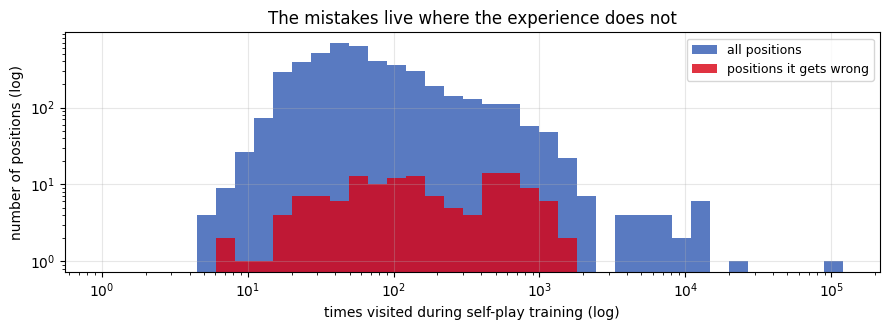

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.logspace(0, np.log10(max(all_counts.max(), 10)), 40)
ax.hist(np.clip(all_counts, 1, None), bins=bins, color=BLUE, alpha=0.65, label="all positions")
ax.hist(np.clip(visit_counts, 1, None), bins=bins, color=RED, alpha=0.8, label="positions it gets wrong")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("times visited during self-play training (log)")
ax.set_ylabel("number of positions (log)")
ax.set_title("The mistakes live where the experience does not")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

The failures sit at the **left** of the distribution - positions the agent barely saw, or never
saw at all.

That is the lecture's convergence condition made concrete: Q-learning converges given
*infinitely many visits to every state-action pair*. Self-play visits sensible positions
constantly and silly ones rarely, so the guarantee simply does not apply where the agent is
weakest. Nothing is broken; the assumption is.

---
# Part 6 - Turn exploration off

### Predict first

Self-play with $\epsilon = 0$: the agent always plays what it currently believes is best,
against a copy of itself doing the same.

> *How many distinct positions do you think it will see in 120,000 games?*

In [21]:
Q_greedy, visits_greedy = train(self_play=True, episodes=120_000, eps_start=0.0, eps_end=0.0)

print(f"distinct positions visited with exploration    : {len(visits_self):,}")
print(f"distinct positions visited with epsilon = 0    : {len(visits_greedy):,}")
print(f"live positions that exist in the whole game    : {len(live):,}")

distinct positions visited with exploration    : 4,520
distinct positions visited with epsilon = 0    : 41
live positions that exist in the whole game    : 4,520


In [22]:
score_greedy, _ = grade(Q_greedy, POSITIONS)
greedy_agent = make_q_policy(Q_greedy)
gx = match(greedy_agent, minimax_policy, 2_000)
go = match(minimax_policy, greedy_agent, 2_000)

print(f"optimal-move rate: {score_greedy:.1%}   (with exploration: {score_self:.1%})")
print(f"vs perfect play, as X: draws {gx['draws']:.1%}, losses {gx['O wins']:.1%}")
print(f"vs perfect play, as O: draws {go['draws']:.1%}, losses {go['X wins']:.1%}")

optimal-move rate: 0.4%   (with exploration: 97.0%)
vs perfect play, as X: draws 14.2%, losses 85.8%
vs perfect play, as O: draws 2.9%, losses 97.1%


### The collapse

With ties broken randomly the agent does still wander a little, but the coverage gap is stark:
tens of thousands of games produce only a small slice of the game tree, because both sides keep
walking down the same handful of lines.

Everything outside those lines is never evaluated, so the agent has no opinion about it - and
a real opponent will happily steer straight into that territory.

This is the $\epsilon$ frame from the lecture, seen from the side the figure could not show.
There we priced what exploration **costs** once you already know the best policy. Here is what
it **buys** while you are still learning.

---
# Part 7 - Try to help it

The agent takes a long time to learn something obvious: **block your opponent when they have
two in a row.** Why not just tell it? Add a small bonus every time it blocks a threat.

This is *reward shaping* - and it is the single most common way people accidentally break an
RL system, so it is worth doing once, deliberately, in a place where nothing is at stake.

In [23]:
def threat_cells(board, player):
    "Cells where `player` would complete a line on the next move."
    out = set()
    for a, b, c in LINES:
        line = [board[a], board[b], board[c]]
        if line.count(player) == 2 and line.count(EMPTY) == 1:
            out.add([a, b, c][line.index(EMPTY)])
    return out

def make_blocking_shaper(bonus_per_block):
    "Bonus for every move that occupied a cell the opponent was threatening to complete."
    def shaper(trajectory):
        bonus = 0.0
        for state, action, _, _ in trajectory:
            # state is canonical: my pieces are 1, the opponent's are 2
            if action in threat_cells(state, 2):
                bonus += bonus_per_block
        return bonus
    return shaper

Run it with a **small** bonus first: $0.3$, well under the $\pm 1$ paid for the actual result.

In [24]:
Q_shaped, _ = train(self_play=True, episodes=120_000, shaping=make_blocking_shaper(0.3))
score_shaped, _ = grade(Q_shaped, POSITIONS)
shaped_agent = make_q_policy(Q_shaped)
sx = match(shaped_agent, minimax_policy, 2_000)
so = match(minimax_policy, shaped_agent, 2_000)

print(f"{'':<28}{'optimal moves':>15}{'loses as X':>13}{'loses as O':>13}")
print(f"{'plain self-play':<28}{score_self:>15.1%}"
      f"{match(selfplay_agent, minimax_policy, 2_000)['O wins']:>13.1%}"
      f"{match(minimax_policy, selfplay_agent, 2_000)['X wins']:>13.1%}")
print(f"{'blocking bonus = 0.3':<28}{score_shaped:>15.1%}{sx['O wins']:>13.1%}{so['X wins']:>13.1%}")

                              optimal moves   loses as X   loses as O


plain self-play                       97.0%         0.0%         0.0%
blocking bonus = 0.3                  99.4%         0.0%         0.0%


### It helped. So what is the catch?

Blocking really is the right move *most* of the time in tic-tac-toe, and the bonus is **small
relative to the real reward**, so it behaves like a hint: it speeds up learning a genuinely
correct habit without ever outvoting the actual outcome.

That is the good case for shaping, and it is worth seeing that the good case exists.

Now break it. Keep the identical heuristic and only turn the dial up, so that blocking pays
**more than winning does**.

In [25]:
Q_greedy_block, _ = train(self_play=True, episodes=120_000, shaping=make_blocking_shaper(3.0))
score_gb, _ = grade(Q_greedy_block, POSITIONS)
gb = make_q_policy(Q_greedy_block)
gbx = match(gb, minimax_policy, 2_000)
gbo = match(minimax_policy, gb, 2_000)

print(f"{'':<28}{'optimal moves':>15}{'loses as X':>13}{'loses as O':>13}")
print(f"{'blocking bonus = 0.3':<28}{score_shaped:>15.1%}{sx['O wins']:>13.1%}{so['X wins']:>13.1%}")
print(f"{'blocking bonus = 3.0':<28}{score_gb:>15.1%}{gbx['O wins']:>13.1%}{gbo['X wins']:>13.1%}")
print()
print("Also: how often does each agent take a winning move when one is available?")

def win_now_rate(Q, n=4_000, seed=7):
    "Fraction of positions with an immediate win available where the agent actually takes it."
    rng = random.Random(seed)
    took, chances = 0, 0
    for board, player in POSITIONS:
        if is_over(board):
            continue
        wins = [c for c in legal_moves(board) if winner(play_move(board, c, player)) == player]
        if not wins:
            continue
        chances += 1
        if greedy_action(Q, board, player, rng, 0.0) in wins:
            took += 1
    return took / chances

print(f"   bonus 0.3 : {win_now_rate(Q_shaped):.1%} of immediate wins taken")
print(f"   bonus 3.0 : {win_now_rate(Q_greedy_block):.1%} of immediate wins taken")

                              optimal moves   loses as X   loses as O
blocking bonus = 0.3                  99.4%         0.0%         0.0%
blocking bonus = 3.0                  84.3%        50.7%        62.4%

Also: how often does each agent take a winning move when one is available?
   bonus 0.3 : 76.0% of immediate wins taken


   bonus 3.0 : 52.5% of immediate wins taken


### There it is

Same heuristic, same code, one number changed - and the agent now **loses to perfect play about
half the time**, from a starting point of never losing at all.

Read the win-taking rates as a *comparison*, not as an absolute: minimax values a delayed
forced win exactly as highly as an immediate one, so even a perfect player does not always take
the win on offer, and the $0.3$ figure is not a count of blunders. What matters is that the
identical measurement on the identical positions **drops sharply** when the only thing changed
is the size of the bonus. The agent is turning down wins it used to take, in order to collect
block payments.

It is not confused and it is not broken. It is optimising exactly what we asked for.

> **The rule:** a shaped reward encodes *your* guess about how to play. While the guess is
> roughly right and the bonus stays small next to the real objective, it is a helpful hint.
> Make it big enough to compete with the real objective and it *becomes* the objective.

This is the reward-hacking frame from the lecture, reproduced deliberately in about ten lines -
and note how ordinary the mistake looks. Nobody wrote "prefer blocking to winning". They wrote
a sensible-looking bonus and picked a number.

---
# Part 8 - Verdict

### "Did it win?" is the wrong question

Tic-tac-toe under perfect play is a **draw**. Against a perfect opponent, winning is not
available to anyone, ever. So the target was never a win rate - it was:

> **can it stop losing?**

Everything in one table.

In [26]:
def summarise(name, Q):
    a = make_q_policy(Q)
    rx, ro = match(a, minimax_policy, 3_000), match(minimax_policy, a, 3_000)
    sc, _ = grade(Q, POSITIONS)
    return {"agent": name, "optimal moves": f"{sc:.1%}",
            "draws vs perfect (X)": f"{rx['draws']:.1%}",
            "loses vs perfect (X)": f"{rx['O wins']:.1%}",
            "draws vs perfect (O)": f"{ro['draws']:.1%}",
            "loses vs perfect (O)": f"{ro['X wins']:.1%}"}

import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

table = pd.DataFrame([summarise("trained vs random", Q_vs_random),
                      summarise("self-play", Q_self),
                      summarise("self-play, no exploration", Q_greedy),
                      summarise("self-play + bonus 0.3", Q_shaped),
                      summarise("self-play + bonus 3.0", Q_greedy_block)]).set_index("agent")
table

,optimal moves,draws vs perfect (X),loses vs perfect (X),draws vs perfect (O),loses vs perfect (O)
agent,,,,,
trained vs random,47.7%,49.2%,50.8%,2.8%,97.2%
self-play,97.0%,100.0%,0.0%,100.0%,0.0%
"self-play, no exploration",0.4%,14.1%,85.9%,2.8%,97.2%
self-play + bonus 0.3,99.4%,100.0%,0.0%,100.0%,0.0%
self-play + bonus 3.0,84.3%,49.0%,51.0%,38.7%,61.3%


### What generalises

1. **The opponent you train against defines what you learn.** Part 2's agent looked excellent
   and was not. Nothing about its win rate revealed the problem - only a stronger opponent did.
2. **Ground truth is worth more than any metric.** Grading every position against minimax told
   us not just *how much* was wrong but *which* positions, and the answer (rarely visited ones)
   explained itself immediately.
3. **The convergence guarantee is about coverage, not time.** More episodes do not help states
   you never reach. Part 6 is what that looks like when it goes wrong.
4. **Shaping a reward means changing the problem.** If the shaped objective differs from the
   real one anywhere, the optimiser will find that place - it is doing its job.
5. **Define success before measuring it.** "Draw against perfect play" is the correct target
   here, and it is not the one a win-rate dashboard would have suggested.

### Where this stops working

Every part of this project depended on tic-tac-toe being small enough to solve exactly:
a few thousand positions, a table in memory, ground truth from a recursion that runs instantly.

Chess has roughly $10^{44}$ positions and Go about $10^{170}$. There is no table, and there is
no minimax answer to grade against. Everything past this point in RL is about coping with
**not knowing the right answer** - which is where DQN, policy gradients, and everything in the
second half of the lecture come from.

### If you want to take it further

- Compare Q-learning to **SARSA** here. Which one is more cautious as O?
- Track how the **opening move preference** changes over training. Does it converge to a corner,
  the centre, or stay indifferent (as minimax says it should)?
- Exploit the board's 8-fold symmetry (rotations and reflections) to shrink the state space.
  How much faster does it learn?
- Try **Connect Four on a 4x4 board** and watch the table stop fitting.